# 2452769 幸可函 第三次课程设计实验报告

### (1) 成功复现实现、运行开源项目，详细说明代码原理、各种操作、算法流程。


In [ ]:
# 基础库：负责路径处理、计时、数值计算和图像显示
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# MindSpore 深度学习框架相关模块
import mindspore as ms
from mindspore import nn, ops, load_checkpoint, load_param_into_net, save_checkpoint
import mindspore.dataset as ds
import mindspore.dataset.vision as vision
import mindspore.dataset.transforms as transforms
import mindspore.common.dtype as mstype

# 统一的随机种子、设备设置与训练步数控制变量。
SEED = 42
DEVICE_TARGET = "CPU"
MAX_TRAIN_STEPS = None

ms.set_seed(SEED)
np.random.seed(SEED)
ms.set_context(mode=ms.PYNATIVE_MODE, device_target=DEVICE_TARGET)

# 数据集与预训练权重路径。
# data_en 已经按 ImageFolder 格式解压，其中 train/test 下每个子目录代表一个类别。
DATA_DIR = Path(r"D:\data_en")
CKPT_PATH = Path(r"D:\mobilenetV2-200_1067.ckpt")
SAVE_PATH = Path(r"D:\save_mobilenetV2_model.ckpt")

class_en = ["Seashell", "Lighter", "Old Mirror", "Broom", "Ceramic Bowl", "Toothbrush", "Disposable Chopsticks", "Dirty Cloth",
            "Newspaper", "Glassware", "Basketball", "Plastic Bottle", "Cardboard", "Glass Bottle", "Metalware", "Hats", "Cans", "Paper",
            "Vegetable Leaf", "Orange Peel", "Eggshell", "Banana Peel", "Battery", "Tablet capsules", "Fluorescent lamp", "Paint bucket"]

# class_index 用于固定“类别名称 -> 数字标签”的对应关系，避免文件夹读取顺序变化影响训练标签。
class_index = {name: i for i, name in enumerate(class_en)}

# 训练参数。
config = {
    "num_classes": 26,
    "image_size": 224,
    "batch_size": 16,
    "epochs": 2,
    "learning_rate": 0.005,
    "momentum": 0.9,
    "weight_decay": 4e-5,
    "max_train_steps": MAX_TRAIN_STEPS,
}

print("MindSpore:", ms.__version__)
print("设备目标:", DEVICE_TARGET)
print("数据集:", DATA_DIR, "存在:", DATA_DIR.exists())
print("训练集:", (DATA_DIR / "train").exists())
print("测试集:", (DATA_DIR / "test").exists())
print("预训练权重:", CKPT_PATH, "存在:", CKPT_PATH.exists())


[WARNING] ME(10272:6404,MainProcess):2026-06-16-19:01:56.312.000 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


MindSpore: 2.9.0
设备目标: CPU
数据集: D:\data_en 存在: True
训练集: True
测试集: True
预训练权重: D:\mobilenetV2-200_1067.ckpt 存在: True


#### 数据集读取与预处理

数据集采用 ImageFolder 结构，MindSpore 根据子文件夹名称生成标签。训练集使用随机裁剪和水平翻转增强，以提升模型对位置和方向变化的鲁棒性；测试集不使用随机操作，仅采用固定缩放和中心裁剪，以保证评估结果稳定。归一化使用 ImageNet 常用均值和标准差，与预训练 MobileNetV2 的输入分布保持一致。


In [2]:
def create_dataset(split, batch_size):
    dataset_path = str(DATA_DIR / split)
    training = split == "train"

    # ImageFolderDataset 会扫描 dataset_path 下的类别文件夹，并把每张图片和标签绑定。
    dataset = ds.ImageFolderDataset(
        dataset_path,
        shuffle=training,
        class_indexing=class_index,
        num_parallel_workers=1,
    )

    # 归一化公式为 (x - mean) / std。mean/std 乘以 255，是因为图像像素仍处在 0~255 范围。
    normalize = vision.Normalize(
        mean=[0.485 * 255, 0.456 * 255, 0.406 * 255],
        std=[0.229 * 255, 0.224 * 255, 0.225 * 255],
    )

    if training:
        # 训练阶段加入随机性，增强模型泛化能力。
        # scale 从 0.5 开始，避免过度裁剪导致垃圾主体被裁掉。
        image_ops = [
            vision.RandomCropDecodeResize(config["image_size"], scale=(0.5, 1.0), ratio=(0.75, 1.333)),
            vision.RandomHorizontalFlip(prob=0.5),
            normalize,
            vision.HWC2CHW(),
        ]
    else:
        # 测试阶段使用确定性预处理，保证每次评估方式一致。
        image_ops = [
            vision.Decode(),
            vision.Resize((256, 256)),
            vision.CenterCrop(config["image_size"]),
            normalize,
            vision.HWC2CHW(),
        ]

    dataset = dataset.map(image_ops, input_columns="image", num_parallel_workers=1)
    dataset = dataset.map(transforms.TypeCast(mstype.int32), input_columns="label", num_parallel_workers=1)
    dataset = dataset.batch(batch_size, drop_remainder=training)
    return dataset


train_dataset = create_dataset("train", config["batch_size"])
test_dataset = create_dataset("test", config["batch_size"])

print("训练 batch 数:", train_dataset.get_dataset_size())
print("测试 batch 数:", test_dataset.get_dataset_size())
print("类别数:", len(class_en))


训练 batch 数: 162
测试 batch 数: 17
类别数: 26


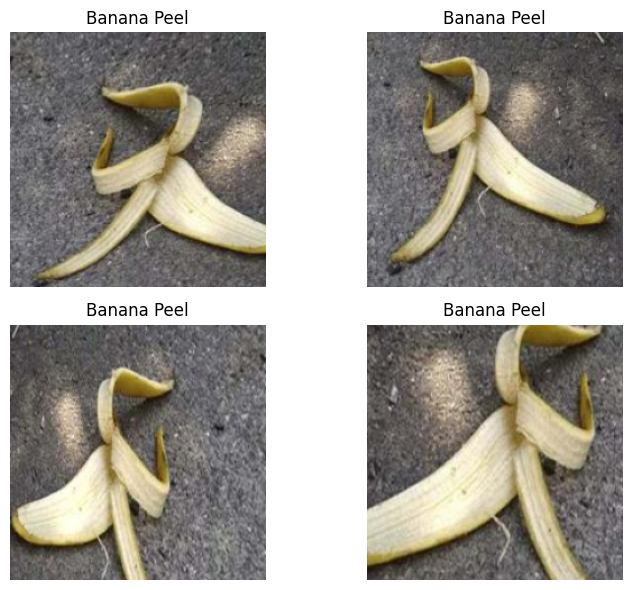

In [3]:
# 展示测试集中的部分样本，检查数据读取和标签映射是否正常。
batch = next(test_dataset.create_dict_iterator(output_numpy=True))
images, labels = batch["image"], batch["label"]

plt.figure(figsize=(8, 6))
for i in range(4):
    # 模型输入是 CHW 格式，matplotlib 显示需要转回 HWC 格式。
    img = np.transpose(images[i], (1, 2, 0))
    # 为了显示图片，需要把归一化后的图像近似反归一化回 0~1 范围。
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(class_en[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()


#### MobileNetV2 网络

代码中 `ConvBNReLU` 表示卷积、批归一化和 ReLU6 激活的组合；`InvertedResidual` 表示 MobileNetV2 的基本残差块；`MobileNetV2Backbone` 负责提取图像特征；`MobileNetV2Head` 负责把特征映射为 26 类输出。


In [4]:
class ConvBNReLU(nn.Cell):
    # 卷积 + 批归一化 + ReLU6，是 MobileNetV2 中反复使用的基础结构。
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, groups=1):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.features = nn.SequentialCell([
            nn.Conv2d(in_channels, out_channels, kernel_size, stride,
                      pad_mode="pad", padding=padding, group=groups, has_bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU6(),
        ])

    def construct(self, x):
        return self.features(x)


class InvertedResidual(nn.Cell):
    # MobileNetV2 倒残差模块。
    # expand_ratio > 1 时先用 1x1 卷积升维，再做深度卷积，最后用 1x1 卷积降维。
    # 当输入输出通道一致且 stride=1 时使用残差连接，有助于梯度传播。
    def __init__(self, inp, oup, stride, expand_ratio):
        super().__init__()
        hidden_dim = int(round(inp * expand_ratio))
        self.use_res_connect = stride == 1 and inp == oup

        layers = []
        if expand_ratio != 1:
            layers.append(ConvBNReLU(inp, hidden_dim, kernel_size=1))
        layers.extend([
            # group=hidden_dim 表示深度卷积，每个通道单独做空间卷积。
            ConvBNReLU(hidden_dim, hidden_dim, stride=stride, groups=hidden_dim),
            # 线性瓶颈层，不接 ReLU，减少信息损失。
            nn.Conv2d(hidden_dim, oup, kernel_size=1, stride=1, has_bias=False),
            nn.BatchNorm2d(oup),
        ])
        self.conv = nn.SequentialCell(layers)

    def construct(self, x):
        return x + self.conv(x) if self.use_res_connect else self.conv(x)


class MobileNetV2Backbone(nn.Cell):
    # MobileNetV2 特征提取网络，对应预训练权重中的 features.* 参数。
    def __init__(self):
        super().__init__()
        input_channel = 32
        self.out_channels = 1280
        # 每一项为 [扩展倍数, 输出通道数, 重复次数, 第一个 block 的步幅]
        setting = [
            [1, 16, 1, 1],
            [6, 24, 2, 2],
            [6, 32, 3, 2],
            [6, 64, 4, 2],
            [6, 96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        features = [ConvBNReLU(3, input_channel, stride=2)]
        for t, c, n, s in setting:
            for i in range(n):
                stride = s if i == 0 else 1
                features.append(InvertedResidual(input_channel, c, stride, expand_ratio=t))
                input_channel = c
        features.append(ConvBNReLU(input_channel, self.out_channels, kernel_size=1))
        self.features = nn.SequentialCell(features)

    def construct(self, x):
        return self.features(x)


class MobileNetV2Head(nn.Cell):
    # 分类头：全局平均池化后接全连接层，输出 26 类 logits。
    def __init__(self, input_channel=1280, num_classes=26):
        super().__init__()
        self.mean = ops.ReduceMean(keep_dims=False)
        self.head = nn.SequentialCell([
            nn.Dropout(p=0.2),
            nn.Dense(input_channel, num_classes),
        ])

    def construct(self, x):
        # Backbone 输出形状为 [N, C, H, W]，对 H/W 取均值得到 [N, C]。
        x = self.mean(x, (2, 3))
        return self.head(x)


class MobileNetV2(nn.Cell):
    # 将 Backbone 和 Head 组合成完整分类网络。
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def construct(self, x):
        return self.head(self.backbone(x))


#### 预训练权重加载与冻结微调

预训练权重来自 MobileNetV2 的源任务分类模型，其中 Backbone 已学习到通用图像特征。本实验仅加载 `features.*` 参数到 Backbone，并冻结这些参数；新建的 Head 输出 26 类并参与训练。该方案复用了通用特征，同时避免在较小数据集上从零训练完整网络。


In [5]:
backbone = MobileNetV2Backbone()

# checkpoint 中既包含 features.*，也包含原任务 head.* 等参数。
# 本实验只加载 features.* 到 Backbone，因为垃圾分类任务需要重新训练 26 类 Head。
param_dict = load_checkpoint(str(CKPT_PATH))
feature_params = {k: v for k, v in param_dict.items() if k.startswith("features.")}
not_loaded, _ = load_param_into_net(backbone, feature_params)

# 冻结 Backbone：这些参数不计算梯度，也不会被优化器更新。
for param in backbone.get_parameters():
    param.requires_grad = False

head = MobileNetV2Head(input_channel=backbone.out_channels, num_classes=config["num_classes"])
network = MobileNetV2(backbone, head)

total_params = sum(int(np.prod(p.shape)) for p in network.get_parameters())
trainable_params = sum(int(np.prod(p.shape)) for p in network.trainable_params())

print("未加载到 Backbone 的参数:", not_loaded)
print("总参数量:", total_params)
print("可训练参数量:", trainable_params)
print("冻结说明: Backbone 已冻结，只训练 Head。")


未加载到 Backbone 的参数: []
总参数量: 2291290
可训练参数量: 33306
冻结说明: Backbone 已冻结，只训练 Head。


#### 训练、测试与模型保存

训练阶段计算交叉熵损失并反向传播，仅更新分类 Head。测试阶段关闭训练状态，统计预测类别与真实标签一致的样本数并计算准确率。每个 epoch 后在测试集上评估一次，并保存测试准确率最高的 checkpoint。


In [ ]:
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
optimizer = nn.Momentum(
    network.trainable_params(),
    learning_rate=config["learning_rate"],
    momentum=config["momentum"],
    weight_decay=config["weight_decay"],
)


def train_one_epoch(model, dataset, loss_fn, optimizer):
    # 训练一个 epoch。
    # 算法流程：
    # 1. 前向传播得到 logits；
    # 2. 用交叉熵计算 loss；
    # 3. 对可训练参数求梯度；
    # 4. 优化器根据梯度更新分类 Head 参数。
    def forward_fn(data, label):
        logits = model(data)
        loss = loss_fn(logits, label)
        return loss

    grad_fn = ms.value_and_grad(forward_fn, None, optimizer.parameters)

    def train_step(data, label):
        loss, grads = grad_fn(data, label)
        optimizer(grads)
        return loss

    model.set_train(True)
    losses = []
    max_steps = config["max_train_steps"]
    

    for step, (data, label) in enumerate(dataset.create_tuple_iterator()):
        if max_steps is not None and step >= max_steps:
            break
        loss = train_step(data, label)
        losses.append(float(loss.asnumpy()))
        
    return float(np.mean(losses))


def evaluate(model, dataset, loss_fn):
    # 在测试集上计算平均损失和准确率。
    model.set_train(False)
    total, correct, losses = 0, 0, []

    for data, label in dataset.create_tuple_iterator():
        logits = model(data)
        loss = loss_fn(logits, label)
        pred = logits.argmax(axis=1)
        correct += int((pred == label).asnumpy().sum())
        total += int(label.shape[0])
        losses.append(float(loss.asnumpy()))

    return {
        "accuracy": correct / total,
        "loss": float(np.mean(losses)),
        "total": total,
        "correct": correct,
    }


history = []
best_result = None
best_accuracy = -1.0
start_time = time.time()

for epoch in range(config["epochs"]):
    print(f"Epoch {epoch + 1}/{config['epochs']}")
    train_loss = train_one_epoch(
        network,
        train_dataset,
        loss_fn,
        optimizer,
    )
    metrics = evaluate(network, test_dataset, loss_fn)
    result = {"epoch": epoch + 1, "train_loss": train_loss, **metrics}
    history.append(result)
    print(f"test accuracy = {metrics['accuracy']:.4f}, test loss = {metrics['loss']:.4f}")

    # 保存测试准确率最高的模型，避免最后一轮出现波动时覆盖较好的 checkpoint。
    if metrics["accuracy"] > best_accuracy:
        best_accuracy = metrics["accuracy"]
        best_result = result
        save_checkpoint(network, str(SAVE_PATH))
        print(f"保存当前最佳模型: accuracy = {best_accuracy:.4f}")

elapsed = time.time() - start_time
print("训练耗时: %.2f 秒" % elapsed)
print("最佳模型已保存:", SAVE_PATH)


Epoch 1/2
test accuracy = 0.8231, test loss = 0.7765
保存当前最佳模型: accuracy = 0.8231
Epoch 2/2
test accuracy = 0.8615, test loss = 0.6250
保存当前最佳模型: accuracy = 0.8615
训练耗时: 48.47 秒
最佳模型已保存: D:\save_mobilenetV2_model.ckpt


#### 算法流程总结

本实验的整体算法流程为：首先读取 `D:\data_en` 中的训练集和测试集，并建立类别到数字标签的映射；然后对训练图像进行随机裁剪、翻转和归一化，对测试图像进行固定缩放、中心裁剪和归一化；接着构建 MobileNetV2 网络，将预训练 checkpoint 中的 `features.*` 参数加载到 Backbone；随后冻结 Backbone，只训练新建的 26 类分类 Head；训练时通过前向传播、交叉熵损失、反向传播和 Momentum 优化器更新 Head；每轮训练后在测试集上计算准确率，并保存测试准确率最高的模型。


### (2) 在(1)的基础上，通过学习开源项目，写了类似的代码，完成模型加载、目标任务迁移与微调。

#### 实验思路

本小题在第 (1) 小题复现流程的基础上，重新组织一套迁移学习代码。预训练模型的源任务是通用图像分类，输出类别数为 1000；本实验的目标任务是 26 类垃圾分类。因此，本部分保留 MobileNetV2 的特征提取部分，重新构造 26 类分类 Head，并只训练目标任务相关参数。


In [ ]:
# 第二小题承接第一小题中已经导入的 MindSpore、数据路径、类别表和 MobileNetV2Backbone。
# 本部分重新组织目标任务配置，以便独立完成迁移学习实验。
ms.set_seed(SEED)
np.random.seed(SEED)

target_config = {
    "num_classes": 26, # 目标类别数
    "image_size": 224,
    "batch_size": 32,
    "epochs": 2,
    "learning_rate": 0.003,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "save_path": Path(r"D:\second_task_mobilenetv2_finetune.ckpt"),
}



#### 目标任务数据集构建

训练集仍使用随机裁剪和翻转增强，测试集使用固定预处理。


In [8]:
def build_target_dataset(split, cfg):
    # 为目标任务构建 MindSpore 数据集。
    is_train = split == "train"
    folder = str(DATA_DIR / split)

    dataset = ds.ImageFolderDataset(
        folder,
        class_indexing=class_index,
        shuffle=is_train,
        num_parallel_workers=1,
    )

    normalize = vision.Normalize(
        mean=[0.485 * 255, 0.456 * 255, 0.406 * 255],
        std=[0.229 * 255, 0.224 * 255, 0.225 * 255],
    )

    if is_train:
        transforms_img = [
            vision.RandomCropDecodeResize(cfg["image_size"], scale=(0.6, 1.0), ratio=(0.8, 1.25)),
            vision.RandomHorizontalFlip(prob=0.5),
            normalize,
            vision.HWC2CHW(),
        ]
    else:
        transforms_img = [
            vision.Decode(),
            vision.Resize((256, 256)),
            vision.CenterCrop(cfg["image_size"]),
            normalize,
            vision.HWC2CHW(),
        ]

    dataset = dataset.map(transforms_img, input_columns="image", num_parallel_workers=1)
    dataset = dataset.map(transforms.TypeCast(mstype.int32), input_columns="label", num_parallel_workers=1)
    dataset = dataset.batch(cfg["batch_size"], drop_remainder=is_train)
    return dataset


target_train_ds = build_target_dataset("train", target_config)
target_test_ds = build_target_dataset("test", target_config)

print("目标任务训练 batch 数:", target_train_ds.get_dataset_size())
print("目标任务测试 batch 数:", target_test_ds.get_dataset_size())


目标任务训练 batch 数: 81
目标任务测试 batch 数: 9


#### 模型加载与任务迁移

从预训练 checkpoint 中加载通用视觉特征参数，并为垃圾分类任务重建 26 类分类 Head，从而完成源任务到目标任务的迁移。


In [9]:
class TargetTaskClassifier(nn.Cell):
    # 面向目标任务重新封装的分类模型。
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.pool = ops.ReduceMean(keep_dims=False)
        self.classifier = nn.Dense(backbone.out_channels, num_classes)

    def construct(self, x):
        features = self.backbone(x)
        pooled = self.pool(features, (2, 3))
        logits = self.classifier(pooled)
        return logits


def load_backbone_for_target_task(ckpt_path):
    # 加载源任务预训练 Backbone，并丢弃源任务分类头。
    backbone = MobileNetV2Backbone()
    ckpt = load_checkpoint(str(ckpt_path))

    # checkpoint 中 features.* 对应 MobileNetV2Backbone；head.* 是源任务分类层，本任务不加载。
    backbone_params = {name: value for name, value in ckpt.items() if name.startswith("features.")}
    load_param_into_net(backbone, backbone_params)
    return backbone

target_backbone = load_backbone_for_target_task(CKPT_PATH)

# 冻结特征提取层，仅训练新分类器，以完成目标任务适配。
for param in target_backbone.get_parameters():
    param.requires_grad = False

target_model = TargetTaskClassifier(target_backbone, target_config["num_classes"])

print("目标任务模型总参数量:", sum(int(np.prod(p.shape)) for p in target_model.get_parameters()))
print("目标任务可训练参数量:", sum(int(np.prod(p.shape)) for p in target_model.trainable_params()))


目标任务模型总参数量: 2291290
目标任务可训练参数量: 33306


#### 自定义训练与评估过程

本实验重新组织训练循环：每个 batch 先进行前向计算，再计算交叉熵损失，随后仅对目标任务分类器求梯度并更新参数。每轮训练结束后在测试集上评估准确率，以观察迁移后的目标任务性能。


In [10]:
def train_target_epoch(model, dataset, loss_fn, optimizer):
    model.set_train(True)
    epoch_losses = []

    def forward_fn(images, labels):
        logits = model(images)
        loss = loss_fn(logits, labels)
        return loss

    grad_fn = ms.value_and_grad(forward_fn, None, optimizer.parameters)

    for images, labels in dataset.create_tuple_iterator():
        loss, grads = grad_fn(images, labels)
        optimizer(grads)
        epoch_losses.append(float(loss.asnumpy()))

    return float(np.mean(epoch_losses))


def evaluate_target_model(model, dataset, loss_fn):
    model.set_train(False)
    correct, total = 0, 0
    losses = []

    for images, labels in dataset.create_tuple_iterator():
        logits = model(images)
        loss = loss_fn(logits, labels)
        pred = logits.argmax(axis=1)
        correct += int((pred == labels).asnumpy().sum())
        total += int(labels.shape[0])
        losses.append(float(loss.asnumpy()))

    return {
        "accuracy": correct / total,
        "loss": float(np.mean(losses)),
        "correct": correct,
        "total": total,
    }


target_loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
target_optimizer = nn.Momentum(
    target_model.trainable_params(),
    learning_rate=target_config["learning_rate"],
    momentum=target_config["momentum"],
    weight_decay=target_config["weight_decay"],
)

target_history = []
target_start = time.time()
best_target_acc = -1.0

for epoch in range(target_config["epochs"]):
    train_loss = train_target_epoch(target_model, target_train_ds, target_loss_fn, target_optimizer)
    metrics = evaluate_target_model(target_model, target_test_ds, target_loss_fn)
    record = {"epoch": epoch + 1, "train_loss": train_loss, **metrics}
    target_history.append(record)

    print(f"epoch {epoch + 1}/{target_config['epochs']}: train_loss={train_loss:.4f}, test_accuracy={metrics['accuracy']:.4f}, test_loss={metrics['loss']:.4f}")
    if metrics["accuracy"] > best_target_acc:
        best_target_acc = metrics["accuracy"]
        save_checkpoint(target_model, str(target_config["save_path"]))

target_elapsed = time.time() - target_start
print("目标任务微调耗时: %.2f 秒" % target_elapsed)


epoch 1/2: train_loss=2.2310, test_accuracy=0.7538, test_loss=1.3122
epoch 2/2: train_loss=0.9666, test_accuracy=0.8077, test_loss=0.8876
目标任务微调耗时: 50.94 秒


#### 结果与说明

本小题完成了从源任务预训练模型到目标任务垃圾分类模型的迁移。实验中加载 MobileNetV2 Backbone 的预训练参数，重新构建 26 类垃圾分类 Head，并冻结 Backbone，仅训练目标任务分类器。训练 2 个 epoch 后，最佳测试准确率为 0.8077，最佳测试损失为 0.8876，测试样本数为 260，微调耗时为 50.94 秒。

该结果说明，使用预训练 Backbone 可以在较短训练时间内完成目标任务迁移。由于 Backbone 中的低层与中层卷积特征已经具备一定通用图像表达能力，因此只训练新的分类 Head 也能得到较好的分类效果。不过，由于 Backbone 完全冻结，模型对垃圾分类数据集的适配能力仍然有限，尤其当目标数据集与预训练源任务存在类别差异时，仅训练分类 Head 难以充分调整特征提取过程。因此，后续进一步比较冻结微调、全量微调和 LoRA 微调，并尝试解冻后部高层特征层以提升模型性能。


### (3) 比较冻结微调、全量微调与 LoRA 微调，并说明其工作原理、冻结层与训练层差异，以及资源占用与效果对比。

#### 对比实验设计

本小题比较三种微调方式：冻结微调、全量微调与 LoRA 微调。三种方法使用相同的数据集、图像尺寸、batch size、损失函数和评估方式，区别仅在于可训练参数的范围。

| 微调方式 | 参与训练的层 | 冻结的层 | 作用 |
|---|---|---|---|
| 冻结微调 | 新建的 26 类分类 Head | MobileNetV2 Backbone 全部层 | 训练成本低，适合小数据集快速迁移 |
| 全量微调 | Backbone 全部层 + 分类 Head | 无 | 模型适应能力强，但训练时间和内存占用更高 |
| LoRA 微调 | 分类 Head 中的 LoRA 低秩矩阵 `lora_A`、`lora_B` | Backbone 全部层、分类器原始权重 | 用少量参数近似权重更新，降低可训练参数量 |

说明：本实验在 CNN 分类任务中将 LoRA 加在最终分类 Head 的 Dense 层上。典型 LoRA 常用于 Transformer 的线性层，本实验采用相同的“低秩增量”思想完成要求中的 LoRA 微调演示。


#### 实验指标与资源记录方法

本小题记录训练时间、CPU 内存变化、可训练参数量、测试准确率和测试损失等指标。由于本实验使用 MindSpore CPU 环境运行，资源占用统计仅记录当前 Python 进程的 CPU 内存变化。三种微调方式均采用相同训练配置，以保证对比结果具有一致性。


In [11]:
import gc
import psutil

process = psutil.Process(os.getpid())


comparison_config = {
    "epochs": 1,
    "batch_size": 16,
    "learning_rate": 0.003,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "lora_rank": 4,
    "lora_alpha": 8,
    "max_train_steps": MAX_TRAIN_STEPS,
}


def cpu_memory_mb():
    return process.memory_info().rss / 1024 / 1024


def count_parameters(model):
    total = sum(int(np.prod(p.shape)) for p in model.get_parameters())
    trainable = sum(int(np.prod(p.shape)) for p in model.trainable_params())
    return total, trainable


cpu_base = cpu_memory_mb()
print("CPU 内存占用基线: %.2f MB" % cpu_base)


CPU 内存占用基线: 4574.20 MB


#### LoRA 分类层

LoRA 的核心思想是冻结原始权重 `W`，只训练一个低秩增量 `A @ B`。若原始 Dense 层为 `xW`，加入 LoRA 后变为 `xW + scale * xAB`。当 rank 很小时，`A` 和 `B` 的参数量远小于完整 `W`，因此可训练参数量更少。


In [12]:
class LoRADense(nn.Cell):
    # 在 Dense 层上加入 LoRA 低秩分支。
    # base 是原始分类器，权重被冻结；lora_A 和 lora_B 是可训练参数。
    def __init__(self, in_features, out_features, rank=4, alpha=8):
        super().__init__()
        self.base = nn.Dense(in_features, out_features)
        for param in self.base.get_parameters():
            param.requires_grad = False

        self.rank = rank
        self.scale = alpha / rank
        self.matmul = ops.MatMul()

        a_init = np.random.normal(0, 0.01, size=(in_features, rank)).astype(np.float32)
        b_init = np.zeros((rank, out_features), dtype=np.float32)
        self.lora_A = ms.Parameter(ms.Tensor(a_init), name="lora_A")
        self.lora_B = ms.Parameter(ms.Tensor(b_init), name="lora_B")

    def construct(self, x):
        base_out = self.base(x)
        lora_out = self.matmul(self.matmul(x, self.lora_A), self.lora_B) * self.scale
        return base_out + lora_out


class ComparisonClassifier(nn.Cell):
    # 三种微调方式共用这个封装，区别在 classifier 类型和 requires_grad 设置。
    def __init__(self, backbone, classifier):
        super().__init__()
        self.backbone = backbone
        self.pool = ops.ReduceMean(keep_dims=False)
        self.classifier = classifier

    def construct(self, x):
        features = self.backbone(x)
        pooled = self.pool(features, (2, 3))
        return self.classifier(pooled)


#### 三种微调模型构建

冻结微调只训练普通 Dense 分类器；全量微调训练 Backbone 和 Dense 分类器；LoRA 微调冻结 Backbone 和分类器原始权重，只训练 `lora_A`、`lora_B` 两个低秩矩阵。


In [13]:
def build_comparison_model(strategy):
    backbone = MobileNetV2Backbone()
    ckpt = load_checkpoint(str(CKPT_PATH))
    backbone_params = {name: value for name, value in ckpt.items() if name.startswith("features.")}
    load_param_into_net(backbone, backbone_params)

    if strategy == "freeze":
        for param in backbone.get_parameters():
            param.requires_grad = False
        classifier = nn.Dense(backbone.out_channels, len(class_en))

    elif strategy == "full":
        for param in backbone.get_parameters():
            param.requires_grad = True
        classifier = nn.Dense(backbone.out_channels, len(class_en))

    elif strategy == "lora":
        for param in backbone.get_parameters():
            param.requires_grad = False
        classifier = LoRADense(
            backbone.out_channels,
            len(class_en),
            rank=comparison_config["lora_rank"],
            alpha=comparison_config["lora_alpha"],
        )

    else:
        raise ValueError("unknown strategy: " + strategy)

    model = ComparisonClassifier(backbone, classifier)
    _, trainable_params = count_parameters(model)

    return model, {
        "strategy": strategy,
        "trainable_params": trainable_params,
    }

#### 统一训练与评估函数

为保证对比公平，三种微调方式共用同一套训练函数和评估函数。训练过程中记录当前 Python 进程的最大 RSS 内存，并以峰值内存与训练前内存的差值衡量 CPU 内存增量。


In [ ]:
def build_comparison_dataset(split):
    # 第三小题单独构建数据集，不依赖第二小题变量。
    is_train = split == "train"
    folder = str(DATA_DIR / split)

    dataset = ds.ImageFolderDataset(
        folder,
        class_indexing=class_index,
        shuffle=is_train,
        num_parallel_workers=1,
    )

    normalize = vision.Normalize(
        mean=[0.485 * 255, 0.456 * 255, 0.406 * 255],
        std=[0.229 * 255, 0.224 * 255, 0.225 * 255],
    )

    if is_train:
        image_ops = [
            vision.RandomCropDecodeResize(224, scale=(0.6, 1.0), ratio=(0.8, 1.25)),
            vision.RandomHorizontalFlip(prob=0.5),
            normalize,
            vision.HWC2CHW(),
        ]
    else:
        image_ops = [
            vision.Decode(),
            vision.Resize((256, 256)),
            vision.CenterCrop(224),
            normalize,
            vision.HWC2CHW(),
        ]

    dataset = dataset.map(image_ops, input_columns="image", num_parallel_workers=1)
    dataset = dataset.map(transforms.TypeCast(mstype.int32), input_columns="label", num_parallel_workers=1)
    dataset = dataset.batch(comparison_config["batch_size"], drop_remainder=is_train)
    return dataset


comparison_train_ds = build_comparison_dataset("train")
comparison_test_ds = build_comparison_dataset("test")
print("第三小题训练 batch 数:", comparison_train_ds.get_dataset_size())
print("第三小题测试 batch 数:", comparison_test_ds.get_dataset_size())


def train_one_strategy(strategy):
    ms.set_seed(SEED)
    np.random.seed(SEED)
    
    gc.collect()
    model, info = build_comparison_model(strategy)
    loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
    optimizer = nn.Momentum(
        model.trainable_params(),
        learning_rate=comparison_config["learning_rate"],
        momentum=comparison_config["momentum"],
        weight_decay=comparison_config["weight_decay"],
    )

    def forward_fn(images, labels):
        logits = model(images)
        loss = loss_fn(logits, labels)
        return loss

    grad_fn = ms.value_and_grad(forward_fn, None, optimizer.parameters)

    start_time = time.time()
    start_cpu = cpu_memory_mb()
    peak_cpu = start_cpu
    train_losses = []

    model.set_train(True)
    for epoch in range(comparison_config["epochs"]):
        epoch_losses = []
        max_steps = comparison_config["max_train_steps"]
        for step, (images, labels) in enumerate(comparison_train_ds.create_tuple_iterator()):
            if max_steps is not None and step >= max_steps:
                break

            loss, grads = grad_fn(images, labels)
            optimizer(grads)
            loss_value = float(loss.asnumpy())
            train_losses.append(loss_value)
            epoch_losses.append(loss_value)

            peak_cpu = max(peak_cpu, cpu_memory_mb())
        print(f"[{strategy}] epoch {epoch + 1}/{comparison_config['epochs']}: train_loss={float(np.mean(epoch_losses)):.4f}")

    model.set_train(False)
    correct, total, eval_losses = 0, 0, []
    for images, labels in comparison_test_ds.create_tuple_iterator():
        logits = model(images)
        eval_loss = loss_fn(logits, labels)
        pred = logits.argmax(axis=1)
        correct += int((pred == labels).asnumpy().sum())
        total += int(labels.shape[0])
        eval_losses.append(float(eval_loss.asnumpy()))

    elapsed = time.time() - start_time
    row = {
        "strategy": strategy,
        "trainable_params": info["trainable_params"],
        "test_accuracy": correct / total,
        "test_loss": float(np.mean(eval_losses)),
        "test_total": total,
        "train_time_sec": elapsed,
        "cpu_mem_start_mb": start_cpu,
        "cpu_mem_peak_mb": peak_cpu,
        "cpu_mem_delta_mb": peak_cpu - start_cpu,
    }

    del model
    gc.collect()
    return row


第三小题训练 batch 数: 162
第三小题测试 batch 数: 17


#### 对比结果

三种微调方式的实验结果如下表所示。表格从可训练参数量、准确率、测试损失、训练时间和 CPU 内存增量等方面进行比较。


In [15]:
comparison_results = []

for strategy in ["freeze", "full", "lora"]:
    result = train_one_strategy(strategy)
    comparison_results.append(result)


headers = [
    "微调方式", "可训练参数量", "准确率", "测试损失", "训练时间(s)",
    "CPU峰值增量(MB)"
]

print("| " + " | ".join(headers) + " |")
print("|" + "|".join(["---"] * len(headers)) + "|")
for row in comparison_results:
    print(
        "| {strategy} | {trainable_params} | {acc:.4f} | {loss:.4f} | {time:.2f} | {cpu_delta:.2f} |".format(
        strategy=row["strategy"],
        trainable_params=row["trainable_params"],
        acc=row["test_accuracy"],
        loss=row["test_loss"],
        time=row["train_time_sec"],
        cpu_delta=row["cpu_mem_delta_mb"],
    )
)


[freeze] epoch 1/1: train_loss=1.8337
[full] epoch 1/1: train_loss=1.5457
[lora] epoch 1/1: train_loss=3.2448
| 微调方式 | 可训练参数量 | 准确率 | 测试损失 | 训练时间(s) | CPU峰值增量(MB) |
|---|---|---|---|---|---|
| freeze | 33306 | 0.7808 | 0.9527 | 23.44 | 428.85 |
| full | 2291290 | 0.8346 | 0.5938 | 74.33 | 610.42 |
| lora | 5224 | 0.1231 | 3.1373 | 23.32 | 421.71 |


#### 对比结果分析

本小题在相同数据集和基本训练设置下比较了冻结微调、全量微调和 LoRA 微调三种方式。实验结果显示，冻结微调只训练新建的 26 类 Dense 分类 Head，可训练参数量为 33306，训练时间为 23.44 秒，测试准确率为 0.7808，测试损失为 0.9527。该方法训练成本较低，CPU 内存增量为 428.85 MB，但由于 Backbone 完全冻结，模型只能通过分类 Head 适配目标任务，因此性能存在一定限制。

全量微调训练 Backbone 和分类 Head 的全部参数，可训练参数量为 2291290，测试准确率达到 0.8346，测试损失降至 0.5938，是三种方法中效果最好的。这说明当 Backbone 参与训练后，模型能够根据垃圾分类数据集进一步调整特征提取过程，从而获得更强的任务适配能力。但全量微调的训练时间为 74.33 秒，CPU 内存增量为 610.42 MB，明显高于冻结微调，说明其性能提升以更高的计算和内存开销为代价。

LoRA 微调只训练分类 Head 中的低秩矩阵 `lora_A` 和 `lora_B`，可训练参数量仅为 5224，是三种方法中最少的，训练时间为 23.32 秒，CPU 内存增量为 421.71 MB，体现了参数高效微调的特点。但在本实验设置下，LoRA 的测试准确率仅为 0.1231，测试损失为 3.1373，效果明显低于冻结微调和全量微调。主要原因是本实验将 LoRA 加在重新初始化的分类 Head 上，同时冻结 Backbone 和分类器原始权重；在训练轮数较少的情况下，低秩增量参数难以充分学习 26 类垃圾分类任务的类别区分能力。因此，本实验结果表明在当前 CNN 分类任务、作用层位置和训练设置下，LoRA 微调效果不理想。

综合来看，全量微调取得了最高准确率和最低测试损失，适合追求分类性能的场景；冻结微调在训练时间和模型效果之间较为平衡，适合计算资源有限或快速迁移的场景；LoRA 微调参数量最少，但需要更合适的作用层选择、初始化方式或训练轮数才能发挥优势。


### (4) 对模型进行改进，以获得更高的准确率。需要保证改进模型前后的超参数设置相同，且需要对前后准确率进行对比。

#### 改进思路

第 (1)(2) 小题中的基础模型采用冻结微调：MobileNetV2 Backbone 全部冻结，只训练最后的 26 类分类 Head。本小题在保持数据集划分、图像尺寸、batch size、epoch、学习率、优化器和损失函数等超参数一致的前提下，对模型可训练结构进行改进。基准模型冻结全部 Backbone，只训练分类 Head；改进模型解冻 MobileNetV2 后部高层特征层 features.13 至 features.18，同时继续训练分类 Head。低层卷积通常学习边缘、颜色、纹理等通用特征，因此继续冻结；后部高层特征更接近类别语义，解冻后可以更好地适配垃圾分类任务。


为保证对比公平，改进前后保持以下超参数一致：数据集划分、图像尺寸、数据预处理、batch size、epoch、学习率、优化器、Momentum、权重衰减和损失函数均相同。唯一变化是模型中参与训练的层不同。

| 项目 | 基准模型 | 改进模型 |
|---|---|---|
| Backbone 预训练权重 | 相同 | 相同 |
| 训练集 / 测试集 | 相同 | 相同 |
| batch size | 相同 | 相同 |
| epoch | 相同 | 相同 |
| 学习率 | 相同 | 相同 |
| 优化器 | 相同 | 相同 |
| 损失函数 | 相同 | 相同 |
| 可训练层 | 只训练 Head | 训练 Head + features.13 至 features.18 |


In [ ]:
improve_config = {
    "image_size": 224,
    "batch_size": 32,
    "epochs": 4,
    "learning_rate": 0.003,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "baseline_save_path": Path(r"D:\q4_baseline_freeze.ckpt"),
    "improved_save_path": Path(r"D:\q4_improved_unfreeze_tail.ckpt"),
}


#### 数据集构建

为了避免数据差异影响结论，基准模型和改进模型共用同一个数据集构建函数。训练集使用随机裁剪和水平翻转，测试集使用固定缩放和中心裁剪。


In [17]:
def build_q4_dataset(split):
    is_train = split == "train"
    dataset = ds.ImageFolderDataset(
        str(DATA_DIR / split),
        class_indexing=class_index,
        shuffle=is_train,
        num_parallel_workers=1,
    )

    normalize = vision.Normalize(
        mean=[0.485 * 255, 0.456 * 255, 0.406 * 255],
        std=[0.229 * 255, 0.224 * 255, 0.225 * 255],
    )

    if is_train:
        image_ops = [
            vision.RandomCropDecodeResize(improve_config["image_size"], scale=(0.6, 1.0), ratio=(0.8, 1.25)),
            vision.RandomHorizontalFlip(prob=0.5),
            normalize,
            vision.HWC2CHW(),
        ]
    else:
        image_ops = [
            vision.Decode(),
            vision.Resize((256, 256)),
            vision.CenterCrop(improve_config["image_size"]),
            normalize,
            vision.HWC2CHW(),
        ]

    dataset = dataset.map(image_ops, input_columns="image", num_parallel_workers=1)
    dataset = dataset.map(transforms.TypeCast(mstype.int32), input_columns="label", num_parallel_workers=1)
    dataset = dataset.batch(improve_config["batch_size"], drop_remainder=is_train)
    return dataset


q4_train_ds = build_q4_dataset("train")
q4_test_ds = build_q4_dataset("test")
print("训练 batch 数:", q4_train_ds.get_dataset_size())
print("测试 batch 数:", q4_test_ds.get_dataset_size())


训练 batch 数: 81
测试 batch 数: 9


#### 模型构建

基准模型加载预训练 Backbone 后冻结所有 features.* 层，仅训练新建的分类 Head。改进模型在同样加载预训练 Backbone 的基础上，解冻 features.13 至 features.18。这些模块位于 MobileNetV2 后部，负责更高层的语义特征提取；让这些层参与训练，可以在保留低层通用视觉特征的同时，使模型的高层特征表达更贴合垃圾分类任务。


In [18]:
class Q4TransferClassifier(nn.Cell):
    # 统一的分类模型封装：Backbone 提取特征，Head 输出 26 类 logits。
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.pool = ops.ReduceMean(keep_dims=False)
        self.classifier = nn.Dense(backbone.out_channels, num_classes)

    def construct(self, x):
        features = self.backbone(x)
        pooled = self.pool(features, (2, 3))
        return self.classifier(pooled)


def build_q4_model(mode):
    backbone = MobileNetV2Backbone()
    ckpt = load_checkpoint(str(CKPT_PATH))
    feature_params = {name: value for name, value in ckpt.items() if name.startswith("features.")}
    load_param_into_net(backbone, feature_params)

    # 先冻结全部 Backbone。
    for param in backbone.get_parameters():
        param.requires_grad = False

    if mode == "baseline":
        trainable_layers = ["classifier"]
    elif mode == "improved":
        # 改进点：只解冻后部高层特征层，保持低层通用特征冻结。
        for name, param in backbone.parameters_and_names():
            if any(name.startswith(f"features.{idx}") for idx in [13, 14, 15, 16, 17, 18]):
                param.requires_grad = True
        trainable_layers = ["features.13", "features.14", "features.15", "features.16", "features.17", "features.18", "classifier"]
     
    else:
        raise ValueError("mode must be 'baseline' or 'improved'")

    model = Q4TransferClassifier(backbone, len(class_en))
    trainable_params = sum(int(np.prod(p.shape)) for p in model.trainable_params())

    return model, {
        "mode": mode,
        "trainable_layers": trainable_layers,
        "trainable_params": trainable_params,
    }



#### 训练与评估函数

基准模型和改进模型共用同一套训练函数。每轮训练后在测试集上评估准确率，并保存测试准确率最高的 checkpoint。


In [ ]:
def q4_train_one_epoch(model, dataset, loss_fn, optimizer):
    model.set_train(True)
    losses = []

    def forward_fn(images, labels):
        logits = model(images)
        loss = loss_fn(logits, labels)
        return loss

    grad_fn = ms.value_and_grad(forward_fn, None, optimizer.parameters)

    for images, labels in dataset.create_tuple_iterator():
        loss, grads = grad_fn(images, labels)
        optimizer(grads)
        losses.append(float(loss.asnumpy()))

    return float(np.mean(losses))


def q4_evaluate(model, dataset, loss_fn):
    model.set_train(False)
    correct, total = 0, 0
    losses = []

    for images, labels in dataset.create_tuple_iterator():
        logits = model(images)
        loss = loss_fn(logits, labels)
        pred = logits.argmax(axis=1)
        correct += int((pred == labels).asnumpy().sum())
        total += int(labels.shape[0])
        losses.append(float(loss.asnumpy()))

    return {
        "accuracy": correct / total,
        "loss": float(np.mean(losses)),
        "correct": correct,
        "total": total,
    }


def q4_run_experiment(mode):
    ms.set_seed(SEED)
    np.random.seed(SEED)
    
    model, info = build_q4_model(mode)
    loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
    optimizer = nn.Momentum(
        model.trainable_params(),
        learning_rate=improve_config["learning_rate"],
        momentum=improve_config["momentum"],
        weight_decay=improve_config["weight_decay"],
    )

    save_path = improve_config["baseline_save_path"] if mode == "baseline" else improve_config["improved_save_path"]
    best_result = None
    start_time = time.time()

    for epoch in range(improve_config["epochs"]):
        train_loss = q4_train_one_epoch(model, q4_train_ds, loss_fn, optimizer)
        metrics = q4_evaluate(model, q4_test_ds, loss_fn)
        record = {"epoch": epoch + 1, "train_loss": train_loss, **metrics}

        print(f"{mode} epoch {epoch + 1}: train_loss={train_loss:.4f}, accuracy={metrics['accuracy']:.4f}, test_loss={metrics['loss']:.4f}")

        if best_result is None or metrics["accuracy"] > best_result["accuracy"]:
            best_result = record
            save_checkpoint(model, str(save_path))

    elapsed = time.time() - start_time
    return {
        **info,
        "best_epoch": best_result["epoch"],
        "best_accuracy": best_result["accuracy"],
        "best_loss": best_result["loss"],
        "test_total": best_result["total"],
        "train_time_sec": elapsed,
        "save_path": save_path,
    }


#### 改进前后实验结果

本小题在相同训练超参数下比较基准模型与改进模型。实验结果从可训练层、可训练参数量、最佳轮次、测试准确率、测试损失和训练时间等方面进行比较。


In [20]:
q4_results = []
for mode in ["baseline", "improved"]:
    q4_results.append(q4_run_experiment(mode))

baseline_result = next(item for item in q4_results if item["mode"] == "baseline")
improved_result = next(item for item in q4_results if item["mode"] == "improved")
accuracy_gain = improved_result["best_accuracy"] - baseline_result["best_accuracy"]

print("| 模型 | 可训练层 | 可训练参数量 | 最佳轮次 | 测试准确率 | 测试损失 | 训练时间(s) |")
print("|---|---|---:|---:|---:|---:|---:|")
for item in q4_results:
    print(
        "| {mode} | {layers} | {params} | {epoch} | {acc:.4f} | {loss:.4f} | {time_sec:.2f} |".format(
            mode=item["mode"],
            layers=", ".join(item["trainable_layers"]),
            params=item["trainable_params"],
            epoch=item["best_epoch"],
            acc=item["best_accuracy"],
            loss=item["best_loss"],
            time_sec=item["train_time_sec"],
        )
    )

print("准确率变化（改进模型 - 基准模型）: %.4f" % accuracy_gain)


baseline epoch 1: train_loss=2.2310, accuracy=0.7538, test_loss=1.3122
baseline epoch 2: train_loss=0.9666, accuracy=0.8077, test_loss=0.8876
baseline epoch 3: train_loss=0.6589, accuracy=0.8269, test_loss=0.7422
baseline epoch 4: train_loss=0.5154, accuracy=0.8385, test_loss=0.6660
improved epoch 1: train_loss=2.0138, accuracy=0.7885, test_loss=0.8656
improved epoch 2: train_loss=0.5858, accuracy=0.8346, test_loss=0.5121
improved epoch 3: train_loss=0.2793, accuracy=0.8731, test_loss=0.4122
improved epoch 4: train_loss=0.1518, accuracy=0.8962, test_loss=0.3681
| 模型 | 可训练层 | 可训练参数量 | 最佳轮次 | 测试准确率 | 测试损失 | 训练时间(s) |
|---|---|---:|---:|---:|---:|---:|
| baseline | classifier | 33306 | 4 | 0.8385 | 0.6660 | 95.07 |
| improved | features.13, features.14, features.15, features.16, features.17, features.18, classifier | 1853402 | 4 | 0.8962 | 0.3681 | 130.82 |
准确率变化（改进模型 - 基准模型）: 0.0577


#### 对比结论

本小题在相同训练超参数下比较基准模型与改进模型。基准模型只训练分类 Head，可训练参数量为 33306；改进模型额外解冻 MobileNetV2 后部高层特征层 `features.13` 至 `features.18`，可训练参数量增加到 1853402。两组实验均训练 4 个 epoch，测试集样本数为 260。

实验结果显示，基准模型的最佳测试准确率为 0.8385，最佳测试损失为 0.6660，训练时间为 95.07 秒；改进模型的最佳测试准确率为 0.8962，最佳测试损失为 0.3681，训练时间为 130.82 秒。与基准模型相比，改进模型的准确率提升了 0.0577，即约 5.77 个百分点；测试损失也从 0.6660 降低到 0.3681，下降较为明显。

该结果说明，解冻 MobileNetV2 后部高层特征层能够有效增强模型对垃圾分类任务的适配能力。其原因在于后部高层特征更接近类别语义，参与训练后可以根据目标数据集重新调整类别相关特征表达，而低层通用视觉特征仍保持冻结，有助于保留预训练模型已经学到的通用视觉特征。与此同时，改进模型的训练时间从 95.07 秒增加到 130.82 秒，可训练参数量也显著增加，说明部分解冻能够提升模型效果，但会带来更高的计算成本。

综合来看，解冻 `features.13` 至 `features.18` 是本实验中有效的模型改进方式。该方法在保持其他超参数一致的前提下明显提高了测试准确率，并显著降低了测试损失，说明改进模型对垃圾分类任务具有更强的适配能力。
